# 사이킷런으로 시작하는 머신러닝

In [1]:
import sklearn

print(sklearn.__version__) # 사이킷런 버전 확인

1.5.1


## 붓꽃 품종 예측하기
Sepal length/width, Petal length/width로 품종 분류

In [2]:
from sklearn.datasets import load_iris                 # 데이터 세트를 생성
from sklearn.tree import DecisionTreeClassifier        # 의사결정트리 알고리즘
from sklearn.model_selection import train_test_split   # 학습 데이터와 테스트 데이터 분리

In [3]:
# 붓꽃 데이터 세트를 로딩한 후, 피처들과 데이터 값이 어떻게 구성돼 있는지 확인한다.

import pandas as pd

# 붓꽃 데이터 세트를 로딩
iris = load_iris()

# iris.data는 Iris 데이터 세트에서 피처(feature)만으로 된 데이터를 numpy로 가지고 있다.
iris_data = iris.data

#iris.target은 붓꽃 데이터 세트에서 레이블(결정 값) 데이터를 numpy로 가지고 있다.
iris_label = iris.target
print('iris target값:', iris_label)
print('iris target명:', iris.target_names)

# 붓꽃 데이터 세트를 자세히 보기 위해 DataFrame으로 변환한다.
iris_df = pd.DataFrame(data=iris_data, columns=iris.feature_names)
iris_df['label']=iris.target
iris_df.head(3)

iris target값: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]
iris target명: ['setosa' 'versicolor' 'virginica']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),label
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0


In [4]:
# 학습용 데이터와 테스트용 데이터를 분리한다.

X_train, X_test, y_train, y_test = train_test_split(iris_data, iris_label, test_size=0.2, random_state=11)

# test_size가 0.2라면, 전체 데이터 중에 test data가 20%라는 뜻
# random_state는 호출할 때마다 같은 학습/테스트 용 데이터 세트를 생성하기 위해 주어지는 난수 발생 값
# 난수 seed 값을 고정해서 호출할 때마다 같은 방식으로 하도록 도와줌

In [5]:
# DecisionTreeClassifier 객체 생성
dt_clf = DecisionTreeClassifier(random_state=11)

# 학습 수행
dt_clf.fit(X_train, y_train) # train data의 feature,label값을 이용해 의사결정 트리 모델을 생성하는 역할

DecisionTreeClassifier(random_state=11)

In [6]:
# feature 데이터로 예측 수행
pred = dt_clf.predict(X_test) # 예측할 때는 반드시 학습시킨 데이터와 다른 데이터를 이용해야 한다.

In [7]:
# '정확도'로 예측 성능 평가
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, pred)
print(f'예측 정확도: {accuracy:.4f}')

예측 정확도: 0.9333


## 사이킷런의 기반 프레임워크 익히기

### Estimator 이해 및 fit(), predict() 메서드
- 지도학습<br>
 Estimator : 지도학습의 모든 알고리즘을 구현한 클래스를 통칭<br>
  Classifier: 분류 알고리즘을 구현한 클래스<br>
  Regressor: 회귀 알고리즘을 구현한 클래스<br>
- 비지도학습<br>
비지도 학습과 피처 추출에서의 fit(): 입력 데이터의 형태에 맞춰 데이터를 변환하기 위한 사전 구조를 맞추는 작업<br>
transform: 입력 데이터의 차원 변환, 클러스터링, 피처 추출 등의 실제 작업<br>
<br><br>
머신러닝 모델을 구축하는 프로세스 <br>
1. 피처의 가공, 변경, 추출을 수행하는 피처 처리
2. ML 알고리즘 학습/예측 수행
3. 모델 평가
<br>다음 과정을 반복한다.

## 내장된 예제 데이터 세트

- data는 피처의 데이터 세트를 가리킴
- target은 분류 시 레이블 값, 회귀일 때는 숫자 결과값 데이터 세트
- target_names는 개별 레이블의 이름을 나타냄
- feature_names는 피처의 이름을 나타냄
- DESCR은 데이터 세트에 대한 설명과 각 피처의 설명

In [8]:
from sklearn.datasets import load_iris

iris_data = load_iris()
print(type(iris_data)) # Python의 딕셔너리 자료형과 유사

<class 'sklearn.utils._bunch.Bunch'>


In [9]:
keys = iris_data.keys()
print('붓꽃 데이터 세트의 키들:', keys)

붓꽃 데이터 세트의 키들: dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [10]:
print('\n feature_names의 type:', type(iris_data.feature_names))
print(' feature_names의 shape:', len(iris_data.feature_names))
print(iris_data.feature_names)

print('\n target_names의 type:', type(iris_data.target_names))
print(' target_names의 shape:', len(iris_data.target_names))
print(iris_data.target_names)

print('\n data의 type:', type(iris_data.data))
print(' data의 shape:', iris_data.data.shape)
print(iris_data.data)

print('\n target의 type:', type(iris_data.target))
print(' target의 shape:', iris_data.target.shape)
print(iris_data.target)


 feature_names의 type: <class 'list'>
 feature_names의 shape: 4
['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']

 target_names의 type: <class 'numpy.ndarray'>
 target_names의 shape: 3
['setosa' 'versicolor' 'virginica']

 data의 type: <class 'numpy.ndarray'>
 data의 shape: (150, 4)
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5

## Model Selection 모듈 소개
학습데이터와 테스트 데이터 분리, 교차 검증 분할 및 평가, Estimator의 하이퍼 파라미터를 튜닝하기 위한 다양함 함수와 클래스를 제공한다.

### 학습/테스트 데이터 세트 분리 - train_test_split()

In [11]:
# 학습한 데이터를 예측할 때 사용한 예시
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

iris = load_iris() # 붓꽃 데이터 불러오기
dt_clf = DecisionTreeClassifier() # 의사결정트리 객체 생성
train_data = iris.data
train_label = iris.target
dt_clf.fit(train_data, train_label)

# 학습 데이터 세트로 예측 수행
pred = dt_clf.predict(train_data)
print('예측 정확도:', accuracy_score(train_label, pred))

예측 정확도: 1.0


In [12]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

df_clf = DecisionTreeClassifier()
iris_data = load_iris()

X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size=0.3, random_state=121)

In [13]:
df_clf.fit(X_train, y_train) # train용 피처와 결과값을 넣는다.
pred = df_clf.predict(X_test) # test용 피처를 넣었을 때, 결과값을 예측한다.
accuracy=accuracy_score(y_test, pred) # 정확한 결과값과 분류 모델의 결과값을 비교한다.
print(f'예측정확도: {accuracy:.4f}')

예측정확도: 0.9556


### 교차 검증
test용 데이터에만 과도하게 최적화되어 과적합(Overfitting)된다.<br>이를 방지하기 위한 방법이, 교차 검증이다.

In [14]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
import numpy as np

iris = load_iris()
features = iris.data
label = iris.target
dt_clf = DecisionTreeClassifier(random_state=156)

# 5개의 폴드 세트로 분리하는 KFold 객체와 폴드 세트별 정확도를 담을 리스트 객체 생성.
kfold = KFold(n_splits = 5)
cv_accuracy = []
print('붓꽃 데이터 세트 크기:', features.shape[0])

붓꽃 데이터 세트 크기: 150


In [15]:
n_iter = 0

# KFold 객체의 split()를 호출하면 폴드별 학습용, 갑증용 테스트의 로우 인덱스를 array로 반환
for train_index, test_index in kfold.split(features):
    X_train, X_test = features[train_index], features[test_index] # kfold.split()으로 반환된 인덱스를 이용해 학습용, 검증용 테스트 데이터 추출
    y_train, y_test = label[train_index], label[test_index]
# 학습 및 예측
    df_clf.fit(X_train, y_train)
    pred = df_clf.predict(X_test)
    n_iter += 1 
# 반복할 때마다 정확도 측정
    accuracy = np.round(accuracy_score(y_test, pred), 4)
    train_size = X_train.shape[0]
    test_size = X_test.shape[0]
    print(f'\n#{n_iter} 교차 검증 정확도: {accuracy}, 학습 데이터 크기: {train_size}, 검증 데이터 크기: {test_size}')
    print(f'#{n_iter} 검증 세트 인덱스: {test_index}')
    cv_accuracy.append(accuracy)

# 개별 iteration별 정확도를 합하여 평균 정확도 계산
print('\n## 평균 검증 정확도:', np.mean(cv_accuracy))


#1 교차 검증 정확도: 1.0, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#1 검증 세트 인덱스: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27 28 29]

#2 교차 검증 정확도: 1.0, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#2 검증 세트 인덱스: [30 31 32 33 34 35 36 37 38 39 40 41 42 43 44 45 46 47 48 49 50 51 52 53
 54 55 56 57 58 59]

#3 교차 검증 정확도: 0.9, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#3 검증 세트 인덱스: [60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 78 79 80 81 82 83
 84 85 86 87 88 89]

#4 교차 검증 정확도: 0.9333, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#4 검증 세트 인덱스: [ 90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119]

#5 교차 검증 정확도: 0.8, 학습 데이터 크기: 120, 검증 데이터 크기: 30
#5 검증 세트 인덱스: [120 121 122 123 124 125 126 127 128 129 130 131 132 133 134 135 136 137
 138 139 140 141 142 143 144 145 146 147 148 149]

## 평균 검증 정확도: 0.92666


### Stratified 폴드
학습/검증 data set에도 원본 data set과 비슷한 label 분포를 유지하기 위함이다. <br>
KFold와 다른 점: 데이터를 분할할 때, split()인자에 feature data 뿐만 아니라 label에 대한 data도 필요하다.

In [16]:
# 기존 KFold 방식의 문제
import pandas as pd

iris = load_iris()
iris_df = pd.DataFrame(data = iris.data, columns = iris.feature_names)
iris_df['label']=iris.target
iris_df['label'].value_counts()

# 3개의 폴드를 형성해서 레이블 분포 확인
kfold = KFold(n_splits = 3)
n_iter = 0
for train_index, test_index in kfold.split(iris_df):
    n_iter += 1
    label_train = iris_df['label'].iloc[train_index]
    label_test = iris_df['label'].iloc[test_index]
    print(f'## 교차검증: {n_iter}')
    print('학습 레이블 데이터 분포:\n', label_train.value_counts())
    print('검증 레이블 데이터 분포:\n', label_test.value_counts())

## 교차검증: 1
학습 레이블 데이터 분포:
 label
1    50
2    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    50
Name: count, dtype: int64
## 교차검증: 2
학습 레이블 데이터 분포:
 label
0    50
2    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
1    50
Name: count, dtype: int64
## 교차검증: 3
학습 레이블 데이터 분포:
 label
0    50
1    50
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
2    50
Name: count, dtype: int64


In [17]:
# StratifiedKFold를 적용했을 때, 레이블 분포 확인

from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits = 3) # K=3인 StratifiedKFold를 객체로 생성
n_iter =0

for train_index, test_index in skf.split(iris_df, iris_df['label']): # feature 데이터와 label 데이터를 인자로 받는다.
    n_iter+=1
    label_train = iris_df['label'].iloc[train_index] # 각 등분된 폴드 마다 train_index, test_index를 Series로 만든다.
    label_test = iris_df['label'].iloc[test_index]
    print(f'*** 교차 검증: {n_iter} ***')
    print('학습 레이블 데이터 분포:\n', label_train.value_counts())
    print('검증 레이블 데이터 분포:\n', label_test.value_counts())


*** 교차 검증: 1 ***
학습 레이블 데이터 분포:
 label
2    34
0    33
1    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    17
1    17
2    16
Name: count, dtype: int64
*** 교차 검증: 2 ***
학습 레이블 데이터 분포:
 label
1    34
0    33
2    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
0    17
2    17
1    16
Name: count, dtype: int64
*** 교차 검증: 3 ***
학습 레이블 데이터 분포:
 label
0    34
1    33
2    33
Name: count, dtype: int64
검증 레이블 데이터 분포:
 label
1    17
2    17
0    16
Name: count, dtype: int64


In [18]:
df_clf = DecisionTreeClassifier(random_state=156)

skfold = StratifiedKFold(n_splits=3)
n_iter=0
cv_accuracy=[]

for train_index, test_index in skfold.split(features, label):
    
    # split한 train, test용 index로 데이터 추출
    X_train, X_test = features[train_index], features[test_index]
    y_train, y_test = label[train_index], label[test_index]

    #학습 및 예측
    df_clf.fit(X_train, y_train)
    pred = df_clf.predict(X_test)

    # 정확도 계산
    n_iter += 1
    accuracy = np.round(accuracy_score(y_test, pred), 4)
    
    train_size = X_train.shape[0]
    test_size = X_test.shape[0]
    print(f'\n#{n_iter} 교차 검증 정확도: {accuracy}, 학습 데이터 크기: {train_size}, 검증 데이터 크기: {test_size}')
    print(f'#{n_iter} 검증 세트 인덱스: {test_index}')
    cv_accuracy.append(accuracy)

# 교차 검증별 정확도 및 평균 정확도 계산
print('\n## 교차 검증별 정확도:', np.round(cv_accuracy, 4))
print('## 평균 검증 정확도:', np.round(np.mean(cv_accuracy)), 4)


#1 교차 검증 정확도: 0.98, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#1 검증 세트 인덱스: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  50
  51  52  53  54  55  56  57  58  59  60  61  62  63  64  65  66 100 101
 102 103 104 105 106 107 108 109 110 111 112 113 114 115]

#2 교차 검증 정확도: 0.94, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#2 검증 세트 인덱스: [ 17  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  67
  68  69  70  71  72  73  74  75  76  77  78  79  80  81  82 116 117 118
 119 120 121 122 123 124 125 126 127 128 129 130 131 132]

#3 교차 검증 정확도: 0.98, 학습 데이터 크기: 100, 검증 데이터 크기: 50
#3 검증 세트 인덱스: [ 34  35  36  37  38  39  40  41  42  43  44  45  46  47  48  49  83  84
  85  86  87  88  89  90  91  92  93  94  95  96  97  98  99 133 134 135
 136 137 138 139 140 141 142 143 144 145 146 147 148 149]

## 교차 검증별 정확도: [0.98 0.94 0.98]
## 평균 검증 정확도: 1.0 4


### 교차 검증을 보다 간편하게 - cross_val_score() 
주요 파라미터
- estimator: Classifier 또는, Regressor
- X: feature data set
- y: label data set
- scoring: 예측 성능 평가 지표 ex. accuracy, ...
- cv: 폴드 개수<br>
scoring 파라미터로 지정된 성능 지표 측정값은 배열 형태로 반환

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, cross_validate
from sklearn.datasets import load_iris

iris_data = load_iris()
df_clf = DecisionTreeClassifier(random_state = 156)

data = iris_data.data
label = iris_data.target

# 성능 지표는 정확도(acccuracy), 교차 검증 세트는 3개
scores = cross_val_score(df_clf, data, label, scoring = 'accuracy', cv=3) # 반환값은 배열 형태
print('교차 검증별 정확도:', np.round(scores, 4))
print('평균 검증 정확도:', np.round(np.mean(scores), 4))

교차 검증별 정확도: [0.98 0.94 0.98]
평균 검증 정확도: 0.9667


### GridSearchCV - 교차 검증과 최적 하이퍼 파라미터 튜닝을 한 번에

In [20]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV

# 데이터를 로딩하고 학습/검증 데이터 분리
iris_data=load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target, test_size=0.2, random_state=156)

dtree = DecisionTreeClassifier()

### 파라미터를 딕셔너리 형태로 설정
parameters = {'max_depth':[1,2,3], 'min_samples_split':[2,3]} # estimator(의사결정트리)의 하이퍼 파라미터를 최적화한다.

import pandas as pd

# param_gridㅡ이 하이퍼 파라미터를 3개의 train, test set fold로 나누어 테스트 수행 설정
### refit =True 가 default임. True면, 가장 좋은 파라미터 설정으로 재학습시킴
grid_dtree = GridSearchCV(dtree, param_grid = parameters, cv =3, refit=True)

# 붓꽃 학습 데이터로 param_grid의 하이퍼 파라미터를 순차적으로 학습/평가
grid_dtree.fit(X_train, y_train)

# GridSearchCV 결과인 cv_results_를 추출해서 DataFrame으로 변환
scores_df = pd.DataFrame(grid_dtree.cv_results_)
scores_df[['params', 'mean_test_score', 'rank_test_score', 'split0_test_score', 'split1_test_score', 'split2_test_score']]

,params,mean_test_score,rank_test_score,split0_test_score,split1_test_score,split2_test_score
0,"{'max_depth': 1, 'min_samples_split': 2}",0.683333,5,0.7,0.675,0.675
1,"{'max_depth': 1, 'min_samples_split': 3}",0.683333,5,0.7,0.675,0.675
2,"{'max_depth': 2, 'min_samples_split': 2}",0.908333,3,0.9,0.925,0.900
3,"{'max_depth': 2, 'min_samples_split': 3}",0.908333,3,0.9,0.925,0.900
4,"{'max_depth': 3, 'min_samples_split': 2}",0.916667,1,0.9,0.950,0.900
5,"{'max_depth': 3, 'min_samples_split': 3}",0.916667,1,0.9,0.950,0.900


In [21]:
# refit = True이기 때문에 최적의 하이퍼 파라미터로 재학습해서 best_estimator_로 저장한다.
estimator=grid_dtree.best_estimator_

# GridSearchCV의 best_estimator_는 이미 최적 학습이 됐기 때문에 별도 학습이 필요 없다.
pred = estimator.predict(X_test)
print(f'테스트 데이터 세트 정확도: {accuracy_score(y_test, pred):.4f}')

테스트 데이터 세트 정확도: 0.9667


## 데이터 전처리
1. 결손값(NaN, Null 값)은 허용되지 않는다.
2. 문자열 값을 입력값으로 허용하지 않는다.

### 데이터 인코딩
- 레이블 인코딩(Label encoding)
- 원-핫 인코딩(One Hot encoding)

#### 레이블 인코딩
문자형 data를 숫자형으로 변환

In [22]:
# 카테고리형 feature에 대한 processing
from sklearn.preprocessing import LabelEncoder

items =['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']

#LabelEncoder를 객체로 생성한 후, fit()과 transform()으로 레이블 인코딩 수행
encoder = LabelEncoder()
encoder.fit(items)
labels= encoder.transform(items)
print('레이블 인코딩 결과:', labels)

레이블 인코딩 결과: [0 1 4 5 3 3 2 2]


In [23]:
print('인코딩 클래스:', encoder.classes_) # 어떤 문자열이 어떤 숫자로 인코딩 됐는지 확인

인코딩 클래스: ['TV' '냉장고' '믹서' '선풍기' '전자레인지' '컴퓨터']


In [24]:
print('디코딩 원본값:', encoder.inverse_transform([4,5,2,0,1,1,3,3])) # 숫자를 다시 디코딩


# 문자열이 숫자로 인코딩되기 때문에, 특정 ML알고리즘에서는 특정 값에 가중치가 더 부과되게 된다.(특히 선형회귀에서는 적용하면 안 된다.)
# 이 문제를 해결한 게 One Hot Encoding

디코딩 원본값: ['전자레인지' '컴퓨터' '믹서' 'TV' '냉장고' '냉장고' '선풍기' '선풍기']


#### 원-핫 인코딩
문자형 data를 칼럼명으로 하는 새로운 feature을 data종류 만큼 만들고 row 길이는 불가피하게 그대로 둔 채로 새로운 피처에 따라  해당 고유 값만 1, 나머지 data는 0으로 채움<br>
주의사항 1. 입력값으로 2차원 데이터가 필요하다. <br>
주의사항 2. 원-핫 인코더의 변환값은 희소 행렬 형태이므로 이를 다시 toarray() 메서드를 이용해서 밀집행렬로 바꿔야 함.

In [25]:
from sklearn.preprocessing import OneHotEncoder
import numpy as np

items =['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']

# 2차원 ndarray로 변환
items = np.array(items).reshape(-1,1)

# 원-핫 인코딩 적용
oh_encoder = OneHotEncoder()
oh_encoder.fit(items)
oh_labels = oh_encoder.transform(items)

# OneHotEncoder()의 반환 결과는 희소 행렬이기 때문에 toarray()를 활용해서 밀집행렬로 바꿔야한다.
print('원-핫 인코딩 데이터')
print(oh_labels.toarray())
print('원-핫 인코딩 데이터 차원')
print(oh_labels.shape)

원-핫 인코딩 데이터
[[1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 1. 0. 0.]
 [0. 0. 1. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0.]]
원-핫 인코딩 데이터 차원
(8, 6)


In [26]:
### 문자열로 이루어진 feature는 DataFrame으로 바꿔서 get_dummies()를 통해 쉽게 구할 수 있다.

import pandas as pd

df = pd.DataFrame({'item':['TV', '냉장고', '전자레인지', '컴퓨터', '선풍기', '선풍기', '믹서', '믹서']})
pd.get_dummies(df)

,item_TV,item_냉장고,item_믹서,item_선풍기,item_전자레인지,item_컴퓨터
0,True,False,False,False,False,False
1,False,True,False,False,False,False
2,False,False,False,False,True,False
3,False,False,False,False,False,True
4,False,False,False,True,False,False
5,False,False,False,True,False,False
6,False,False,True,False,False,False
7,False,False,True,False,False,False


### 피처 스케일링(StandardScaler, MinMaxScaler)과 정규화(벡터 정규화)
서로 다른 변수(feature)의 값 범위를 일정한 수준으로 맞추는 작업 (수치 크기에 민감한 ML알고리즘을 위한)

#### StandardScaler (=표준화)
서포트 벡터 머신(Support Vector Machine, SVM), 선형 회귀(Linear Regression), 로지스틱 회귀(Logistic Regression)에서는 데이터가 가우시안 분포를 가지고 있다고 가정하기 때문에 사전에 표준화 과정을 거치는 것이 매우 중요할 수 있다.<br>
* 가우시안 분포: 데이터의 피처 각각이 평균이 0이고 분산이 1인 분포

In [27]:
# preprocessing 하기 전의 data 평균과 분산

from sklearn.datasets import load_iris
import pandas as pd

# 붓꽃 데이터를 불러와서 DataFrame 형태로 변환
iris= load_iris()
iris_data=iris.data
iris_df = pd.DataFrame(data = iris_data, columns=iris.feature_names)

print('feature들의 평균 값:\n', iris_df.mean())
print('\n feature들의 분산 값:\n', iris_df.var())

feature들의 평균 값:
 sepal length (cm)    5.843333
sepal width (cm)     3.057333
petal length (cm)    3.758000
petal width (cm)     1.199333
dtype: float64

 feature들의 분산 값:
 sepal length (cm)    0.685694
sepal width (cm)     0.189979
petal length (cm)    3.116278
petal width (cm)     0.581006
dtype: float64


In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler() # StandardScaler 객체 생성
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df) # fit(), transform()으로 데이터 세트 변환

# ndarray -> DataFrame
iris_df_scaled = pd.DataFrame(data = iris_scaled, columns = iris.feature_names)
print('feature들의 평균 값:\n', iris_df_scaled.mean())
print('\n feature들의 분산 값:\n', iris_df_scaled.var()) # 정규 분포에 맞게 분산이 1에 수렴한다. var()는 분산

feature들의 평균 값:
 sepal length (cm)   -1.690315e-15
sepal width (cm)    -1.842970e-15
petal length (cm)   -1.698641e-15
petal width (cm)    -1.409243e-15
dtype: float64

 feature들의 분산 값:
 sepal length (cm)    1.006711
sepal width (cm)     1.006711
petal length (cm)    1.006711
petal width (cm)     1.006711
dtype: float64


#### MinMaxScaler
각 피처의 데이터는 (x-min)/(max-min)의 공식에 의해 변환되기 때문에, 최소 0 최대 1의 값의 범위를 갖는다.

In [29]:
from sklearn.preprocessing import MinMaxScaler

# MinMaxScaler 객체 생성
scaler = MinMaxScaler()
# fit(), transform()으로 데이터 세트 변환
scaler.fit(iris_df)
iris_scaled = scaler.transform(iris_df)

# DataFrame으로 변환
iris_df_scaled = pd.DataFrame(data = iris_scaled, columns=iris.feature_names)
print('feature들의 평균 값:\n', iris_df_scaled.mean())
print('\n feature들의 분산 값:\n', iris_df_scaled.var())

feature들의 평균 값:
 sepal length (cm)    0.428704
sepal width (cm)     0.440556
petal length (cm)    0.467458
petal width (cm)     0.458056
dtype: float64

 feature들의 분산 값:
 sepal length (cm)    0.052908
sepal width (cm)     0.032983
petal length (cm)    0.089522
petal width (cm)     0.100869
dtype: float64


#### 학습 데이터와 테스트 데이터의 스케일링 변환 시 유의점
- fit(): 데이터 변환을 위한 기준 정보 설정(ex. 데이터 세트의 최댓값/최솟값 설정 등)을 적용
- transform(): 데이터를 변환
- fit_transform(): fit()과 transform()을 한 번에 적용
<br>* 주의사항<br>
테스트 데이터의 스케일링 변환할 때는 학습 데이터로 적용한 기준 정보 설정만을 사용해야한다. <br>
scaler 객체에 학습 데이터 따로, 테스트 데이터 따로 fit(), transform()하면 기준 정보 설정이 달라져서 올바른 예측 결과를 도출하기 힘들다.

In [30]:
# 테스트 데이터에 fit()을 적용하면 발생하는 일
from sklearn.preprocessing import MinMaxScaler
import numpy as np

#학습데이터(0~10), 테스트 데이터(0~5) 세트 생성
train_array = np.arange(0,11).reshape(-1,1) # scaler 클래스의 fit(), transform()은 2차원 이상 데이터만 가능 -> reshape(-1,1) 사용
test_array = np.arange(0,6).reshape(-1,1)

scaler = MinMaxScaler() # feature_range 파라미터의 default = (0,1)

scaler.fit(train_array) # train_array의 최소0 최대 10으로 설정
train_scaled = scaler.transform(train_array) # 1/10 스케일로 train_array 변환

print('원본 train_array 데이터:', train_array.reshape(-1))
print('Scale된 train_array 데이터:', np.round(train_scaled.reshape(-1),2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


In [31]:
# MinMaxScaler에 test_array의 최솟값이 0, 최댓값이 5로 설정된다.
scaler.fit(test_array)

# test_array로 맞춘 기준 정보 설정 때문에 1/5 스케일로 변환된다.
test_scaled = scaler.transform(test_array)

print('원본 test_array 데이터:', np.round(test_array.reshape(-1),2))
print('Scale된 test_array 데이터:', np.round(test_scaled.reshape(-1),2))

원본 test_array 데이터: [0 1 2 3 4 5]
Scale된 test_array 데이터: [0.  0.2 0.4 0.6 0.8 1. ]


In [32]:
scaler = MinMaxScaler()
scaler.fit(train_array)
train_scaled = scaler.transform(train_array)
print('원본 train_array 데이터:', train_array.reshape(-1))
print('Scale된 train_array 데이터:', np.round(train_scaled.reshape(-1),2))

# test_array에 Scale 변환을 할 때는 반드시 fit()을 호출하지 않고 transform()만으로 변환해야 함
test_scaled = scaler.transform(test_array)
print('원본 test_array 데이터:', np.round(test_array.reshape(-1),2))
print('Scale된 test_array 데이터:', np.round(test_scaled.reshape(-1),2))

원본 train_array 데이터: [ 0  1  2  3  4  5  6  7  8  9 10]
Scale된 train_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]
원본 test_array 데이터: [0 1 2 3 4 5]
Scale된 test_array 데이터: [0.  0.1 0.2 0.3 0.4 0.5]


1. 가능하다면, 전체 데이터의 스케일링 변환을 진행한 뒤에 학습과 테스트 데이터로 분리
2. 과정1이 여의치 않다면, 테스트 데이터 변환 시에는 fit()이나 fit_transform()을 적용하지 않고 이미 train data로 fit된 scaler 객체에 그대로 transform을 넣으면 된다.

## 사이킷런으로 수행하는 타이타닉 생존자 예측

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

titanic_df = pd.read_csv('./titanic_train.csv')
titanic_df.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


In [34]:
print('\n### 학습 데이터 정보 ###\n')
print(titanic_df.info())


### 학습 데이터 정보 ###

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None


In [35]:
titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)
titanic_df['Cabin'].fillna('N', inplace=True)
titanic_df['Embarked'].fillna('N', inplace=True)
print('데이터 세트 Null 값 개수', titanic_df.isnull().sum().sum())

데이터 세트 Null 값 개수 0


C:\Users\kikio\AppData\Local\Temp\ipykernel_24064\2646065124.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  titanic_df['Age'].fillna(titanic_df['Age'].mean(), inplace=True)
C:\Users\kikio\AppData\Local\Temp\ipykernel_24064\2646065124.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as 

In [36]:
print('Sex 값 분포 :\n', titanic_df['Sex'].value_counts())
print('\n Cacbin 값 분포 :\n', titanic_df['Cabin'].value_counts())
print('\n Embarked 값 분포 :\n', titanic_df['Embarked'].value_counts())

Sex 값 분포 :
 Sex
male      577
female    314
Name: count, dtype: int64

 Cacbin 값 분포 :
 Cabin
N              687
C23 C25 C27      4
G6               4
B96 B98          4
C22 C26          3
              ... 
E34              1
C7               1
C54              1
E36              1
C148             1
Name: count, Length: 148, dtype: int64

 Embarked 값 분포 :
 Embarked
S    644
C    168
Q     77
N      2
Name: count, dtype: int64


In [37]:
titanic_df['Cabin'] = titanic_df['Cabin'].str[0] # 좌석 등급만 나오게 첫 문자만 추출
print(titanic_df['Cabin'].head(3))

0    N
1    C
2    N
Name: Cabin, dtype: object


In [38]:
titanic_df.groupby(['Sex', 'Survived'])['Survived'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Survived, dtype: int64

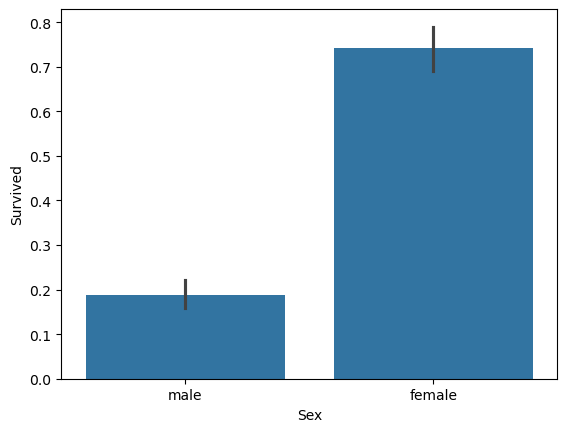

In [39]:
sns.barplot(x='Sex', y='Survived', data=titanic_df)
plt.show()
# 성별이 생존에 영향을 미침

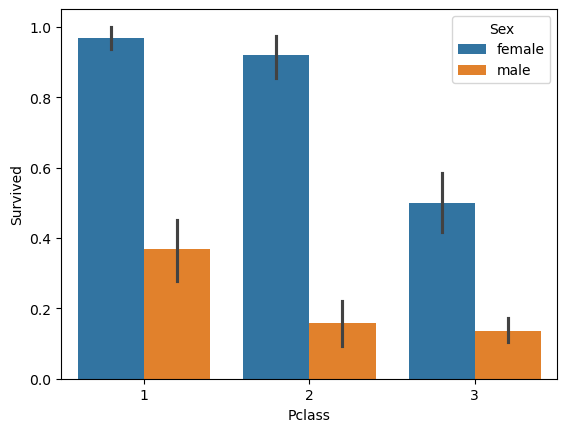

In [40]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data= titanic_df)
plt.show()
# 좌석 등급마다 성별의 생존률 비교

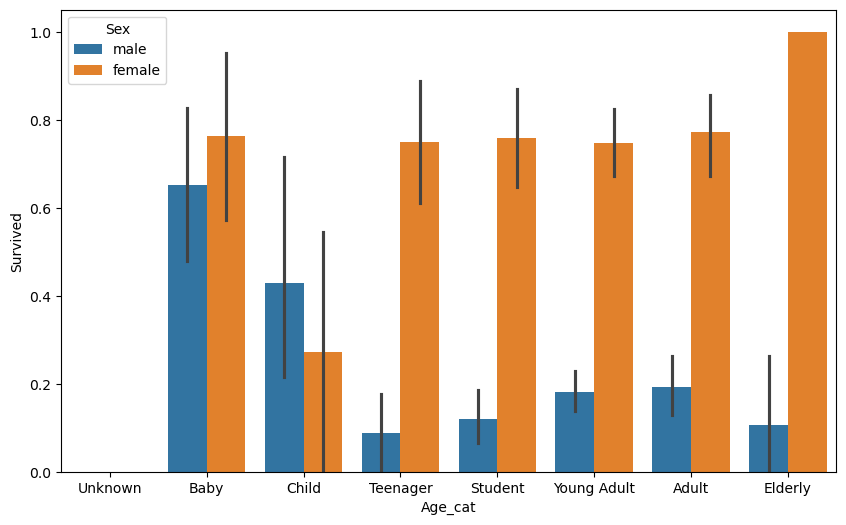

In [41]:
# 나이에 따른 분류
def get_category(age):
    cat = ''
    if age <= -1: cat = 'Unknown'
    elif age <= 5: cat = 'Baby'
    elif age <= 12: cat = 'Child'
    elif age <= 18: cat = 'Teenager'
    elif age <= 25: cat = 'Student'
    elif age <= 35: cat = 'Young Adult'
    elif age <= 60: cat = 'Adult'
    else : cat = 'Elderly'
    
    return cat

plt.figure(figsize=(10,6))

group_names = ['Unknown', 'Baby', 'Child', 'Teenager', 'Student', 'Young Adult', 'Adult', 'Elderly']
# apply lambda 식 활용
titanic_df['Age_cat'] = titanic_df['Age'].apply(lambda x : get_category(x))
sns.barplot(x='Age_cat', y='Survived', hue='Sex', data=titanic_df, order=group_names)
titanic_df.drop('Age_cat', axis=1, inplace=True)
plt.show()

In [42]:
# 남아있는 문자열 카테고리 피처를 숫자형 카테고리 피처로 변환
from sklearn.preprocessing import LabelEncoder

def encode_features(dataDF):
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(dataDF[feature])
        dataDF[feature] = le.transform(dataDF[feature])

    return dataDF

titanic_df = encode_features(titanic_df)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,7,3
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,2,0
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,7,3
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,2,3
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,7,3


In [43]:
#null 처리 함수
def fillna(df):
    df['Age'].fillna(df['Age'].mean(), inplace=True)
    df['Cabin'].fillna('N', inplace=True)
    df['Embarked'].fillna('N', inplace=True)
    df['Fare'].fillna(0, inplace=True)
    return df

#머신러닝 알고리즘에 불필요한 feature 제거
def drop_features(df):
    df.drop(['PassengerId', 'Name', 'Ticket'], axis=1, inplace=True)
    return df

#레이블 인코딩 수행
def format_features(df):
    df['Cabin']=df['Cabin'].str[:1]
    features = ['Cabin', 'Sex', 'Embarked']
    for feature in features:
        le = LabelEncoder()
        le = le.fit(df[feature])
        df[feature] = le.transform(df[feature])
    return df

#앞에서 설정한 데이터 전처리 함수 호출
def transform_features(df):
    df = fillna(df)
    df = drop_features(df)
    df = format_features(df)
    return df

In [44]:
# 원본 데이터를 재로딩, 피처 데이터 세트와 레이블 데이터 세트 추출
titanic_df = pd.read_csv('titanic_train.csv')
y_titanic_df = titanic_df['Survived']
X_titanic_df = titanic_df.drop('Survived', axis=1)

X_titanic_df = transform_features(X_titanic_df)

# train_test_split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(X_titanic_df, y_titanic_df, test_size=0.2, random_state=11)

C:\Users\kikio\AppData\Local\Temp\ipykernel_24064\2599875294.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)
C:\Users\kikio\AppData\Local\Temp\ipykernel_24064\2599875294.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For exa

In [45]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

#사이킷런 Classifier 클래스를 객체로 생성
dt_clf = DecisionTreeClassifier(random_state=11)
rf_clf = RandomForestClassifier(random_state=11)
lr_clf = LogisticRegression(solver='liblinear')

# DecisionTreeClassifier fit/predict/accuracy
dt_clf.fit(X_train , y_train)
dt_pred = dt_clf.predict(X_test)
print('DecisionTreeClassifier 정확도: {0:.4f}'.format(accuracy_score(y_test, dt_pred)))

# RandomForestClassifier fit/predict/accuracy
rf_clf.fit(X_train , y_train)
rf_pred = rf_clf.predict(X_test)
print('RandomForestClassifier 정확도:{0:.4f}'.format(accuracy_score(y_test, rf_pred)))

# LogisticRegression fit/predict/accuracy
lr_clf.fit(X_train , y_train)
lr_pred = lr_clf.predict(X_test)
print('LogisticRegression 정확도: {0:.4f}'.format(accuracy_score(y_test, lr_pred)))

DecisionTreeClassifier 정확도: 0.7877
RandomForestClassifier 정확도:0.8547
LogisticRegression 정확도: 0.8659


In [46]:
# KFold 클래스, n_split = 5

from sklearn.model_selection import KFold

def exec_kfold(clf, folds=5):
    kfold = KFold(n_splits=folds)
    scores=[]

    #KFold 교차 검증 수행
    for iter_count, (train_index, test_index) in enumerate(kfold.split(X_titanic_df)):
        
        #x_titanic_df 데이터에서 교차 검증별로 학습과 검증 데이터를 가리키는 index 생성
        X_train, X_test = X_titanic_df.values[train_index], X_titanic_df.values[test_index]
        y_train, y_test = y_titanic_df.values[train_index], y_titanic_df.values[test_index]
        
        #classifier 학습, 예측, 정확도
        clf.fit(X_train, y_train)
        predictions = clf.predict(X_test)
        accuracy = accuracy_score(y_test, predictions)
        scores.append(accuracy)
        
        print("교차 검증 {0} 정확도: {1:.4f}".format(iter_count, accuracy))

    #5개 fold에서의 평균 정확도 계산
    mean_score = np.mean(scores)
    print("평균 정확도: {0:.4f}".format(mean_score))

# exec_kfold 호출
exec_kfold(dt_clf, folds=5)

교차 검증 0 정확도: 0.7542
교차 검증 1 정확도: 0.7809
교차 검증 2 정확도: 0.7865
교차 검증 3 정확도: 0.7697
교차 검증 4 정확도: 0.8202
평균 정확도: 0.7823


In [47]:
# cross_val_score

from sklearn.model_selection import cross_val_score

scores = cross_val_score(dt_clf, X_titanic_df, y_titanic_df, cv=5)
for iter_count, accuracy in enumerate(scores):
    print("교차 검증 {0} 정확도: {1:.4f}".format(iter_count,accuracy))

print("평균 정확도: {0:.4f}".format(np.mean(scores)))

교차 검증 0 정확도: 0.7430
교차 검증 1 정확도: 0.7753
교차 검증 2 정확도: 0.7921
교차 검증 3 정확도: 0.7865
교차 검증 4 정확도: 0.8427
평균 정확도: 0.7879


In [48]:
# GridSearchCV

from sklearn.model_selection import GridSearchCV

parameters = {'max_depth':[2,3,5,10], 'min_samples_split':[2,3,5], 'min_samples_leaf': [1,5,8]}
grid_dclf = GridSearchCV(dt_clf, param_grid=parameters, scoring='accuracy', cv=5)
grid_dclf.fit(X_train, y_train)

print('GridSearchCV 최적 하이퍼 파라미터:', grid_dclf.best_params_)
print('GridSearchCV 최고 정확도: {0:.4f}'.format(grid_dclf.best_score_))
best_dclf = grid_dclf.best_estimator_

#gridsearchcv의 최적 하이퍼 파라미터로 학습된 estimator로 예측 및 평가 수행
dpredictions = best_dclf.predict(X_test)
accuracy = accuracy_score(y_test, dpredictions)
print('테스트 세트에서의 DecisionTreeClassifier 정확도: {0:.4f}'.format(accuracy))

GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2}
GridSearchCV 최고 정확도: 0.7992
테스트 세트에서의 DecisionTreeClassifier 정확도: 0.8715
